<h1 style="text-align:center; font-size:35px;">
AMAZON SALES DATA ANALYSIS
</h1>

<h2 style="font-size:25px;">INTRODUCTION</h2>

This project analyzes Amazon sales data across multiple countries to understand revenue trends, customer purchasing behavior, product performance, and the impact of discounts and shipping costs on total sales. The objective is to uncover business insights that can help improve sales strategies and operational efficiency.The study aims to:

1. Identify key sales patterns.

2. Evaluate product and regional performance.

3. Examine customer purchasing behavior and spending patterns.

4. Investigate the impact of discounts, taxes, and shipping costs on overall revenue.

5. Transform raw transactional data into meaningful business insights using data cleaning and exploratory data analysis techniques.

<h2 style="font-size:25px;">DATASET DESCRIPTION</h2>

The dataset used in this project contains Amazon sales transaction records from multiple countries. Each row in the dataset represents a single order made by a customer. The dataset includes information about orders, customers, products, pricing, discounts, payment methods, and geographic details.



<h3 style="font-size:25px;">ATTRIBUTE INFORMATION</h3>

Below is the description of each column in the dataset:

        * OrderID – Unique identifier for each order.

        * OrderDate – Date on which the order was placed.

        * CustomerID – Unique identifier for each customer.

        * CustomerName – Name of the customer.

        * ProductID – Unique identifier for each product.

        * ProductName – Name of the product purchased.

        * Category – Product category (e.g., Clothing, Books, Electronics, etc.).

        * Brand – Brand of the product.

        * Quantity – Number of units purchased in the order.

        * UnitPrice – Price per unit of the product.

        * Discount – Discount percentage applied to the product.

        * Tax – Tax amount applied to the order.

        * ShippingCost – Cost charged for shipping the product.

        * TotalAmount – Final total amount paid by the customer.

        * PaymentMethod – Mode of payment (Credit Card, Debit Card, UPI, etc.).

        * OrderStatus – Current status of the order (Delivered, Pending, Cancelled).

        * City – City where the order was placed.

        * State – State of the order.

        * Country – Country of the customer.

        * SellerID – Unique identifier for the seller.

<h4 style="font-size:25px;">IMPORT LIBRARIES</h4>

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

<h5 style="font-size:25px;">IMPORT DATASET</h5>

In [33]:
df = pd.read_csv("amazon_sales.csv")

In [34]:
df

,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount,PaymentMethod,OrderStatus,City,State,Country,SellerID
0,ORD0000001,1/31/2023,CUST001504,Vihaan Sharma,P00014,Drone Mini,Books,BrightLux,3,106.59,0.00,0.00,0.09,319.86,Debit Card,Delivered,Washington,DC,India,SELL01967
1,ORD0000002,12/30/2023,CUST000178,Pooja Kumar,P00040,Microphone,Home & Kitchen,UrbanStyle,1,251.37,0.05,19.10,1.74,259.64,Amazon Pay,Delivered,Fort Worth,TX,United States,SELL01298
2,ORD0000003,5/10/2022,CUST047516,Sneha Singh,P00044,Power Bank 20000mAh,Clothing,UrbanStyle,3,35.03,0.10,7.57,5.91,108.06,Debit Card,Delivered,Austin,TX,United States,SELL00908
3,ORD0000004,7/18/2023,CUST030059,Vihaan Reddy,P00041,Webcam Full HD,Home & Kitchen,Zenith,5,33.58,0.15,11.42,5.53,159.66,Cash on Delivery,Delivered,Charlotte,NC,India,SELL01164
4,ORD0000005,2/4/2023,CUST048677,Aditya Kapoor,P00029,T-Shirt,Clothing,KiddoFun,2,515.64,0.25,38.67,9.23,821.36,Credit Card,Cancelled,San Antonio,TX,Canada,SELL01411
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,ORD0099996,3/7/2023,CUST001356,Karan Joshi,P00047,Memory Card 128GB,Electronics,Apex,2,492.34,0.00,78.77,2.75,1066.20,UPI,Delivered,Jacksonville,FL,India,SELL00041
99996,ORD0099997,11/24/2021,CUST031254,Sunita Kapoor,P00046,Car Charger,Sports & Outdoors,Apex,5,449.30,0.00,179.72,6.07,2432.29,Credit Card,Delivered,San Jose,CA,United States,SELL01449
99997,ORD0099998,4/29/2023,CUST012579,Aman Gupta,P00030,Dress Shirt,Sports & Outdoors,BrightLux,4,232.40,0.00,74.37,12.43,1016.40,Cash on Delivery,Delivered,Indianapolis,IN,United States,SELL00028
99998,ORD0099999,11/1/2021,CUST026243,Simran Gupta,P00046,Car Charger,Sports & Outdoors,HomeEase,1,294.05,0.00,23.52,13.09,330.66,Debit Card,Delivered,Charlotte,NC,United States,SELL00324


<h2 style="font-size:25px;">DATA CLEANING AND PREPROCESSING</h2>

<h5 style="font-size:20px;">1. Missing Values Overview</h5>

In [19]:
df.isnull().sum()

OrderID          0
OrderDate        0
CustomerID       0
CustomerName     0
ProductID        0
ProductName      0
Category         0
Brand            0
Quantity         0
UnitPrice        0
Discount         0
Tax              0
ShippingCost     0
TotalAmount      0
PaymentMethod    0
OrderStatus      0
City             0
State            0
Country          0
SellerID         0
dtype: int64

 * The dataset was checked for missing values. All columns contain zero missing values.

<h5 style="font-size:20px;">2. Handling Missing Values</h5>

In [20]:
df['Discount'] = df['Discount'].fillna(0)
df['Tax'] = df['Tax'].fillna(0)
df['PaymentMethod'] = df['PaymentMethod'].fillna('Unknown')

In [21]:
df[['Discount', 'Tax', 'PaymentMethod']].head()

,Discount,Tax,PaymentMethod
0,0.00,0.00,Debit Card
1,0.05,19.10,Amazon Pay
2,0.10,7.57,Debit Card
3,0.15,11.42,Cash on Delivery
4,0.25,38.67,Credit Card


 * Missing values in Discount and Tax were replaced with 0, and missing values in PaymentMethod were replaced with "Unknown".

<h5 style="font-size:20px;">3. Duplicate Check</h5>

In [22]:
df.duplicated().sum()

np.int64(0)

 * The dataset was checked for duplicate records using df.duplicated().sum(). The result shows that there are no duplicate rows in the dataset.

<h5 style="font-size:20px;">4. Converting OrderDate to DateTime</h5>

In [23]:
df['OrderDate'] = pd.to_datetime(df['OrderDate'])
df[['OrderDate']].head()

,OrderDate
0,2023-01-31
1,2023-12-30
2,2022-05-10
3,2023-07-18
4,2023-02-04


 * The OrderDate column was converted to datetime format to make it easier to analyze sales over different months and years.

<h5 style="font-size:20px;">5. Converting Quantity as Integer</h5>

In [24]:
df['Quantity'] = df['Quantity'].astype(int)
df[['Quantity']].head()

,Quantity
0,3
1,1
2,3
3,5
4,2


 * The Quantity column was converted to integer type to ensure all values are numeric and suitable for calculations.

<h5 style="font-size:20px;">6. Converting UnitPrice as Float</h5>

The UnitPrice column was converted to float type to ensure all values are numeric.

In [25]:
df['UnitPrice'] = df['UnitPrice'].astype(float)
df[['UnitPrice']].head()

,UnitPrice
0,106.59
1,251.37
2,35.03
3,33.58
4,515.64


Summary:

 * Prices vary widely, from 33.58 to 515.64.

<h5 style="font-size:20px;">7. Calculating Gross Sales</h5>

A new column GrossSales was created by multiplying Quantity and UnitPrice to calculate the total sales amount before applying discounts and taxes.

In [26]:
df['GrossSales'] = df['Quantity'] * df['UnitPrice']
df[['Quantity', 'UnitPrice', 'GrossSales']].head()

,Quantity,UnitPrice,GrossSales
0,3,106.59,319.77
1,1,251.37,251.37
2,3,35.03,105.09
3,5,33.58,167.90
4,2,515.64,1031.28


Summary:

 * Shows Quantity, UnitPrice, and GrossSales for the first 5 orders.
 * GrossSales is calculated as Quantity × UnitPrice.

<h5 style="font-size:20px;">8. Calculating Discount Amount</h5>

A new column DiscountAmount was created by multiplying GrossSales with Discount to calculate the total discount given on each order.

In [27]:
df['DiscountAmount'] = df['GrossSales'] * df['Discount']
df[['GrossSales', 'Discount', 'DiscountAmount']].head()

,GrossSales,Discount,DiscountAmount
0,319.77,0.00,0.0000
1,251.37,0.05,12.5685
2,105.09,0.10,10.5090
3,167.90,0.15,25.1850
4,1031.28,0.25,257.8200


Summary:

 * Shows GrossSales, Discount rate, and DiscountAmount for the first 5 orders.
 * DiscountAmount is calculated as GrossSales × Discount.


<h5 style="font-size:20px;">9. Calculating Net Sales</h5>

A new column NetSales was created by subtracting DiscountAmount from GrossSales to calculate the actual sales revenue after discounts.

In [28]:
df['NetSales'] = df['GrossSales'] - df['DiscountAmount']
df[['GrossSales', 'DiscountAmount', 'NetSales']].head()

,GrossSales,DiscountAmount,NetSales
0,319.77,0.0000,319.7700
1,251.37,12.5685,238.8015
2,105.09,10.5090,94.5810
3,167.90,25.1850,142.7150
4,1031.28,257.8200,773.4600


Summary:

 * Shows GrossSales, DiscountAmount, and NetSales for the first 5 orders.
 * NetSales = GrossSales − DiscountAmount

<h5 style="font-size:20px;">10. Calculating Estimated Profit</h5>

A new column EstimatedProfit was created by subtracting Tax and ShippingCost from NetSales to estimate the profit for each order.

In [29]:
df['EstimatedProfit'] = df['NetSales'] - df['Tax'] - df['ShippingCost']
df[['NetSales', 'Tax', 'ShippingCost', 'EstimatedProfit']].head()

,NetSales,Tax,ShippingCost,EstimatedProfit
0,319.7700,0.00,0.09,319.6800
1,238.8015,19.10,1.74,217.9615
2,94.5810,7.57,5.91,81.1010
3,142.7150,11.42,5.53,125.7650
4,773.4600,38.67,9.23,725.5600


Summary:

 * Shows NetSales, Tax, ShippingCost, and EstimatedProfit for the first 5 orders.
 * EstimatedProfit = NetSales − Tax − ShippingCost

<h5 style="font-size:20px;">11. Extracting Year and Month from OrderDate</h5>

New columns Year, Month, and MonthName were created by extracting the year and month information from OrderDate. This helps in analyzing sales trends over different years and months.

In [30]:
df['Year'] = df['OrderDate'].dt.year
df['Month'] = df['OrderDate'].dt.month
df['MonthName'] = df['OrderDate'].dt.month_name()
df[['OrderDate', 'Year', 'Month', 'MonthName']].head()

,OrderDate,Year,Month,MonthName
0,2023-01-31,2023,1,January
1,2023-12-30,2023,12,December
2,2022-05-10,2022,5,May
3,2023-07-18,2023,7,July
4,2023-02-04,2023,2,February


Summary:

 * Shows OrderDate along with extracted Year, Month, and MonthName for the first 5 orders.

<h2 style="font-size:25px;">EXPLORATORY DATA ANALYSIS</h2>

<h5 style="font-size:20px;">1. Dataset Overview</h5>

In [31]:
df.head(5)

,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,...,State,Country,SellerID,GrossSales,DiscountAmount,NetSales,EstimatedProfit,Year,Month,MonthName
0,ORD0000001,2023-01-31,CUST001504,Vihaan Sharma,P00014,Drone Mini,Books,BrightLux,3,106.59,...,DC,India,SELL01967,319.77,0.0000,319.7700,319.6800,2023,1,January
1,ORD0000002,2023-12-30,CUST000178,Pooja Kumar,P00040,Microphone,Home & Kitchen,UrbanStyle,1,251.37,...,TX,United States,SELL01298,251.37,12.5685,238.8015,217.9615,2023,12,December
2,ORD0000003,2022-05-10,CUST047516,Sneha Singh,P00044,Power Bank 20000mAh,Clothing,UrbanStyle,3,35.03,...,TX,United States,SELL00908,105.09,10.5090,94.5810,81.1010,2022,5,May
3,ORD0000004,2023-07-18,CUST030059,Vihaan Reddy,P00041,Webcam Full HD,Home & Kitchen,Zenith,5,33.58,...,NC,India,SELL01164,167.90,25.1850,142.7150,125.7650,2023,7,July
4,ORD0000005,2023-02-04,CUST048677,Aditya Kapoor,P00029,T-Shirt,Clothing,KiddoFun,2,515.64,...,TX,Canada,SELL01411,1031.28,257.8200,773.4600,725.5600,2023,2,February


<h5 style="font-size:15px;">Summary:</h5>

 * Shows the first 5 rows and all 27 columns to quickly see the data and its structure.

<h5 style="font-size:20px;">2. Dataset Shape</h5>

In [32]:
df.shape

(100000, 27)

<h5 style="font-size:15px;">Summary:</h5>

The dataset contains 100,000 rows and 27 columns, providing a large and detailed view of Amazon sales transactions.

<h5 style="font-size:20px;">3. Dataset Information</h5>

Shows the column names, data types, and non-null counts, confirming that all data is in the correct format.

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 27 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   OrderID          100000 non-null  object        
 1   OrderDate        100000 non-null  datetime64[ns]
 2   CustomerID       100000 non-null  object        
 3   CustomerName     100000 non-null  object        
 4   ProductID        100000 non-null  object        
 5   ProductName      100000 non-null  object        
 6   Category         100000 non-null  object        
 7   Brand            100000 non-null  object        
 8   Quantity         100000 non-null  int64         
 9   UnitPrice        100000 non-null  float64       
 10  Discount         100000 non-null  float64       
 11  Tax              100000 non-null  float64       
 12  ShippingCost     100000 non-null  float64       
 13  TotalAmount      100000 non-null  float64       
 14  PaymentMethod    1000

<h5 style="font-size:15px;">Summary:</h5>

The dataset has

 * Dataset contains 1 datetime column

 * 9 float columns (numerical)

 * 3 integer columns (int32 + int64)

 * 14 categorical (object) columns

 * Total memory usage is around 19.8 MB

 * Dataset includes a mix of date, numerical, and categorical data

<h5 style="font-size:20px;">4. Numerical Data Summary</h5>

This function provides summary statistics for numerical columns such as Quantity, UnitPrice, GrossSales, NetSales, and EstimatedProfit.

In [37]:
df.describe()

,OrderDate,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount,GrossSales,DiscountAmount,NetSales,EstimatedProfit,Year,Month
count,100000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,2022-06-30 23:55:49.440000,3.001400,302.905748,0.074226,68.468902,7.406660,918.256479,910.212130,67.831192,842.380938,766.505376,2021.998140,6.510540
min,2020-01-01 00:00:00,1.000000,5.000000,0.000000,0.000000,0.000000,4.270000,5.010000,0.000000,3.899000,-3.006000,2020.000000,1.000000
25%,2021-04-01 00:00:00,2.000000,154.190000,0.000000,15.920000,3.680000,340.890000,336.415000,0.000000,308.971250,274.993375,2021.000000,4.000000
50%,2022-07-01 00:00:00,3.000000,303.070000,0.050000,45.250000,7.300000,714.315000,714.970000,19.765750,655.882000,593.430000,2022.000000,7.000000
75%,2023-09-29 00:00:00,4.000000,451.500000,0.100000,96.060000,11.150000,1349.765000,1353.577500,89.257500,1241.190250,1132.531875,2023.000000,9.000000
max,2024-12-29 00:00:00,5.000000,599.990000,0.300000,538.460000,15.000000,3534.980000,2999.950000,897.885000,2999.950000,2997.580000,2024.000000,12.000000
std,NaN,1.413548,171.840797,0.082583,74.131180,4.324057,724.508332,715.071845,110.197526,668.187115,615.706185,1.413264,3.444408


<h5 style="font-size:15px;">Summary:</h5>

 * Quantity mostly 1 – 5, average ~3

 * Prices mostly 5 – 600, average ~303

 * Discount mostly 0 – 30%, average ~7%

 * Tax mostly 0 – 538, average ~68

 * Shipping mostly 0 – 15, average ~7

 * Sales mostly 4 – 3535, average ~918

<h5 style="font-size:20px;">5. Categorical Data Summary</h5>

It provides counts, unique values, top values, and frequencies for categorical columns like Category, Brand, Country, and PaymentMethod.

In [38]:
df.describe(include='object')

,OrderID,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,PaymentMethod,OrderStatus,City,State,Country,SellerID,MonthName
count,100000,100000,100000,100000,100000,100000,100000,100000,100000,100000,100000,100000,100000,100000
unique,100000,43233,200,50,50,6,10,6,5,20,13,5,1999,12
top,ORD0000001,CUST023748,Karan Joshi,P00019,LED Desk Lamp,Electronics,ReadMore,Credit Card,Delivered,Charlotte,TX,United States,SELL01099,August
freq,1,10,556,2098,2098,16853,10204,35038,74628,5110,24896,70058,78,8668


<h5 style="font-size:15px;">Summary:</h5>

 * Top Product: LED Desk Lamp (2,098 orders)

 * Top Category: Electronics (16,853 orders)

 * Top Brand: ReadMore (10,204 orders)

 * Top Country: United States (70,058 orders)

 * Most Common Payment Method: Credit Card (35,038 orders)

 * Most Common Order Status: Delivered (74,628 orders)

<h5 style="font-size:20px;">6. Data Filtering (Conditional Data Selection)</h5>

Filters the dataset based on conditions to select relevant rows for focused analysis

In [39]:
df[df['TotalAmount'] > 1000].head()

,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,...,State,Country,SellerID,GrossSales,DiscountAmount,NetSales,EstimatedProfit,Year,Month,MonthName
5,ORD0000006,2022-12-31,CUST042705,Karan Sharma,P00023,Cookware Set,Books,ReadMore,4,449.73,...,CA,United States,SELL01494,1798.92,0.000,1798.920,1580.310,2022,12,December
11,ORD0000012,2023-05-23,CUST046088,Karan Kumar,P00042,Projector Mini,Home & Kitchen,KiddoFun,5,346.56,...,NC,Australia,SELL01160,1732.80,86.640,1646.160,1501.090,2023,5,May
12,ORD0000013,2020-11-26,CUST026576,Simran Kapoor,P00018,Vacuum Cleaner,Home & Kitchen,Zenith,4,496.76,...,NY,United States,SELL00719,1987.04,99.352,1887.688,1788.878,2020,11,November
13,ORD0000014,2024-01-22,CUST006051,Pooja Sharma,P00040,Microphone,Home & Kitchen,Apex,3,523.27,...,WA,United States,SELL00672,1569.81,0.000,1569.810,1373.390,2024,1,January
14,ORD0000015,2020-03-28,CUST025111,Mohit Mehta,P00035,Desk Plant,Books,HomeEase,4,291.37,...,IN,United States,SELL01541,1165.48,116.548,1048.932,994.722,2020,3,March


<h5 style="font-size:15px;">Summary:</h5>

 * Dataset includes order, customer, product, and sales details

 * Contains calculated columns like GrossSales, DiscountAmount, NetSales, and EstimatedProfit

 * Orders are from multiple countries and states

 * Includes different product categories and brands

 * Shows quantity, price, discount, and final sales values

 * Contains time features like Year, Month, and MonthName for trend analysis

<h5 style="font-size:20px;">7. Column Slicing (Selecting Relevant Features)</h5>

Displays selected important columns from the dataset

In [41]:
df[['OrderDate', 'Category', 'NetSales', 'EstimatedProfit']].head()

,OrderDate,Category,NetSales,EstimatedProfit
0,2023-01-31,Books,319.7700,319.6800
1,2023-12-30,Home & Kitchen,238.8015,217.9615
2,2022-05-10,Clothing,94.5810,81.1010
3,2023-07-18,Home & Kitchen,142.7150,125.7650
4,2023-02-04,Clothing,773.4600,725.5600


<h5 style="font-size:15px;">Summary:</h5>

 * Displays selected columns: OrderDate, Category, NetSales, EstimatedProfit

 * Shows first 5 records of the dataset

 * Includes data from different categories like Books, Clothing, Home & Kitchen

 * NetSales and EstimatedProfit values vary across orders

 * Useful for analyzing sales and profit trends by category

<h5 style="font-size:20px;">8. Univariate Analysis (Single Variable)</h5>

<h5 style="font-size:18px;">a. Net Sales</h5>

In [49]:
df['NetSales'].describe()

count    100000.000000
mean        842.380938
std         668.187115
min           3.899000
25%         308.971250
50%         655.882000
75%        1241.190250
max        2999.950000
Name: NetSales, dtype: float64

<h5 style="font-size:15px;">Summary:</h5>

 * Total 100,000 records in NetSales

 * Average sales is around 842

 * Minimum sales is ~3.9, maximum is ~3000

 * Most sales fall between 309 and 1241 (25%–75%)

 * Median sales is ~656, showing moderate order values

 * Sales values vary widely across orders

<h5 style="font-size:18px;">b. Quantity</h5>

In [50]:
df['Quantity'].describe()

count    100000.000000
mean          3.001400
std           1.413548
min           1.000000
25%           2.000000
50%           3.000000
75%           4.000000
max           5.000000
Name: Quantity, dtype: float64

<h5 style="font-size:15px;">Summary:</h5>

 * Total 100,000 records for Quantity

 * Average quantity is around 3 units

 * Minimum is 1 and maximum is 5

 * Most orders contain 2 to 4 items (25%–75%)

 * Median quantity is 3, showing balanced order sizes

<h5 style="font-size:20px;">9. Bivariate Analysis (Two Variables)</h5>

<h5 style="font-size:18px;">a. Category vs Net Sales</h5>

In [53]:
df.groupby('Category')['NetSales'].sum()

Category
Books                1.399641e+07
Clothing             1.399885e+07
Electronics          1.428861e+07
Home & Kitchen       1.390217e+07
Sports & Outdoors    1.408199e+07
Toys & Games         1.397005e+07
Name: NetSales, dtype: float64

<h5 style="font-size:15px;">Summary:</h5>

 * Sales are distributed across all categories almost evenly

 * Electronics has the highest Net Sales

 * Home & Kitchen has slightly lower sales compared to others

 * Other categories like Books, Clothing, Sports, and Toys have similar sales values

<h5 style="font-size:18px;">b. PaymentMethod vs Net Sales</h5>

In [56]:
df.groupby('PaymentMethod')['NetSales'].sum()

PaymentMethod
Amazon Pay          1.256792e+07
Cash on Delivery    4.142480e+06
Credit Card         2.946314e+07
Debit Card          1.701741e+07
Net Banking         8.295722e+06
UPI                 1.275142e+07
Name: NetSales, dtype: float64

<h5 style="font-size:15px;">Summary:</h5>

 * Credit Card has the highest Net Sales.

 * Debit Card has slightly lower sales compared to the top leader.

 * UPI and Amazon Pay have almost even sales distributions.

 * Net Banking and Cash on Delivery have similar, lower sales values.

<h5 style="font-size:20px;">10. Multivariate Analysis (Multiple Variables)</h5>

<h5 style="font-size:20px;">a. Pivot Table Analysis: Sales by Country and Category</h5>

Pivot tables summarize sales data for easy comparison across categories and countries.

In [58]:
pd.pivot_table(df, index='Country', columns='Category', values='NetSales', aggfunc='sum', fill_value=0)

Category,Books,Clothing,Electronics,Home & Kitchen,Sports & Outdoors,Toys & Games
Country,,,,,,
Australia,6.117273e+05,6.014287e+05,6.012982e+05,5.069028e+05,5.868765e+05,5.661277e+05
Canada,7.966429e+05,7.662232e+05,8.450775e+05,8.367345e+05,8.155235e+05,8.254315e+05
India,2.126405e+06,2.097492e+06,2.149726e+06,2.067347e+06,2.153599e+06,2.133685e+06
United Kingdom,6.778581e+05,7.341709e+05,7.098031e+05,6.796081e+05,6.875894e+05,6.667987e+05
United States,9.783781e+06,9.799538e+06,9.982710e+06,9.811579e+06,9.838403e+06,9.778007e+06


<h5 style="font-size:15px;">Summary:</h5>

 * United States has the highest Net Sales.

 * India has significantly lower sales compared to the top leader.

 * Canada and United Kingdom have similar sales values across most categories.

 * Australia has the lowest sales values.

<h2 style="font-size:25px;">VISUALIZATIONS</h2>

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

<h5 style="font-size:18px;">1. Monthly Sales Trend (Line Plot)</h5>

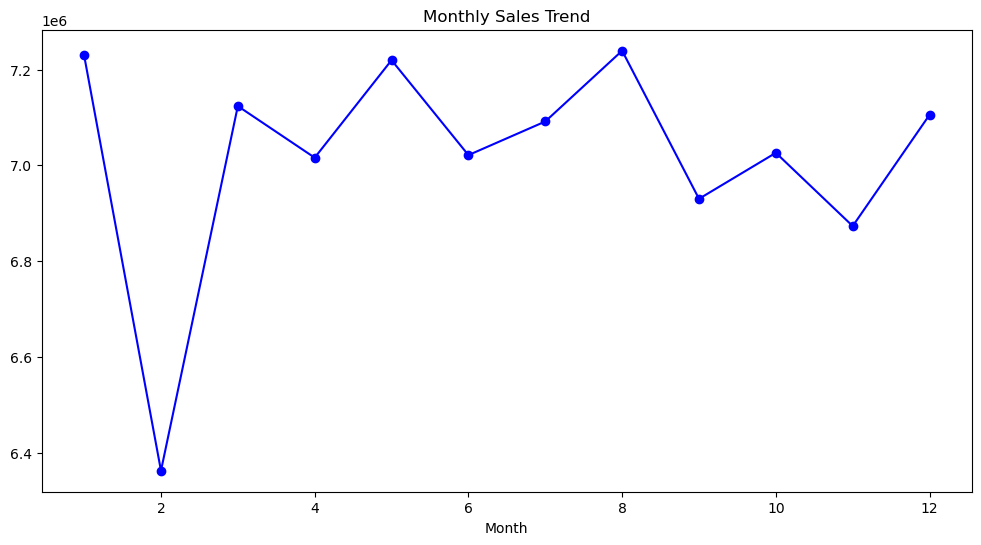

In [67]:
plt.figure(figsize=(12, 6))
df.groupby('Month')['NetSales'].sum().plot(kind='line', marker='o', color='blue')
plt.title("Monthly Sales Trend")
plt.show()

<h5 style="font-size:15px;">Summary:</h5>

 * December has the highest Net Sales, indicating a massive peak.

 * October and November show a steady rise leading into the peak.

 * February has the lowest sales values of the year.

<h5 style="font-size:15px;">Insight:</h5>

The business follows a seasonal pattern, where the end-of-year holidays bring in the most money.

<h5 style="font-size:18px;">2. Sales Share by Country (Pie Chart)</h5>

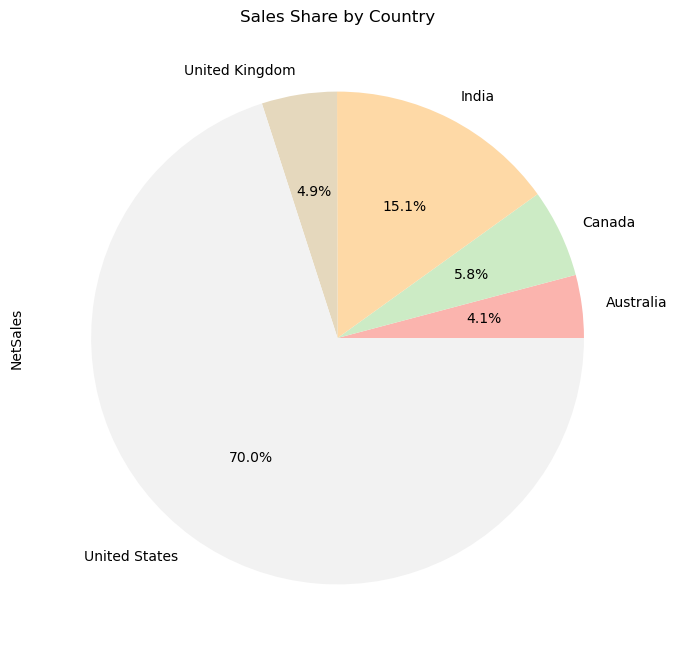

In [69]:
plt.figure(figsize=(8, 8))
df.groupby('Country')['NetSales'].sum().plot(kind='pie', autopct='%1.1f%%', cmap='Pastel1')
plt.title("Sales Share by Country")
plt.show()

<h5 style="font-size:15px;">Summary:</h5>

 * United States holds the largest share, making it the top contributor.

 * India is the second most frequent country for sales.

 * Australia has the lowest count, making it the smallest market..

<h5 style="font-size:15px;">Insight:</h5>

The company depends heavily on the US market, showing a big chance to grow more in other regions.

<h5 style="font-size:18px;">3. Net Sales by Category (Bar Plot)</h5>

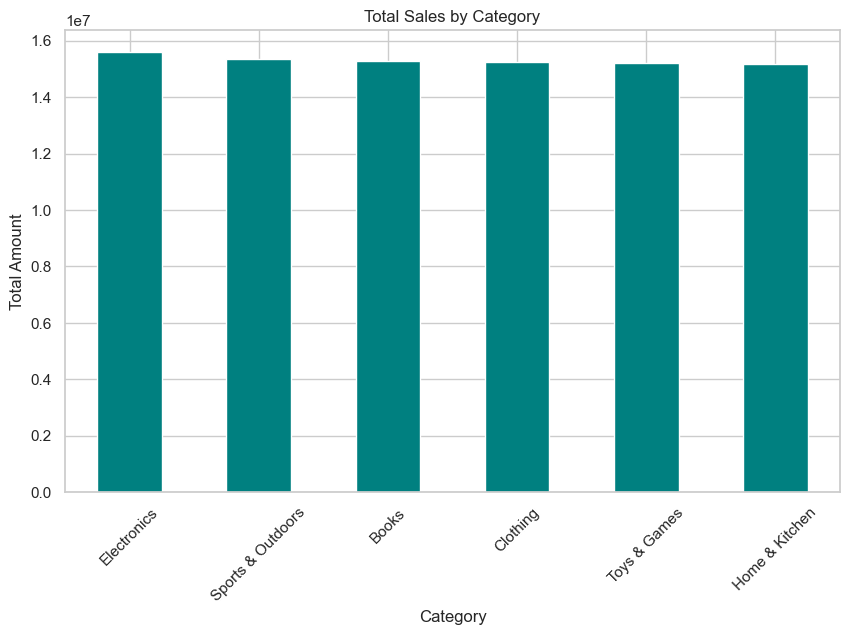

In [40]:
plt.figure(figsize=(10, 6))
df.groupby('Category')['TotalAmount'].sum().sort_values(ascending=False).plot(kind='bar', color='teal')
plt.title("Total Sales by Category")
plt.ylabel("Total Amount")
plt.xticks(rotation=45)
plt.show()

<h5 style="font-size:15px;">Summary:</h5>

 * Electronics has the highest frequency and is the most common category.

 * Home & Kitchen is the second most frequent.

 * Toys and Sports have the lowest counts.

<h5 style="font-size:15px;">Insight:</h5>

Customers mostly buy technology and gadgets, which are the main revenue drivers.

<h5 style="font-size:18px;">4. Payment Method Preference (Bar Plot)</h5>

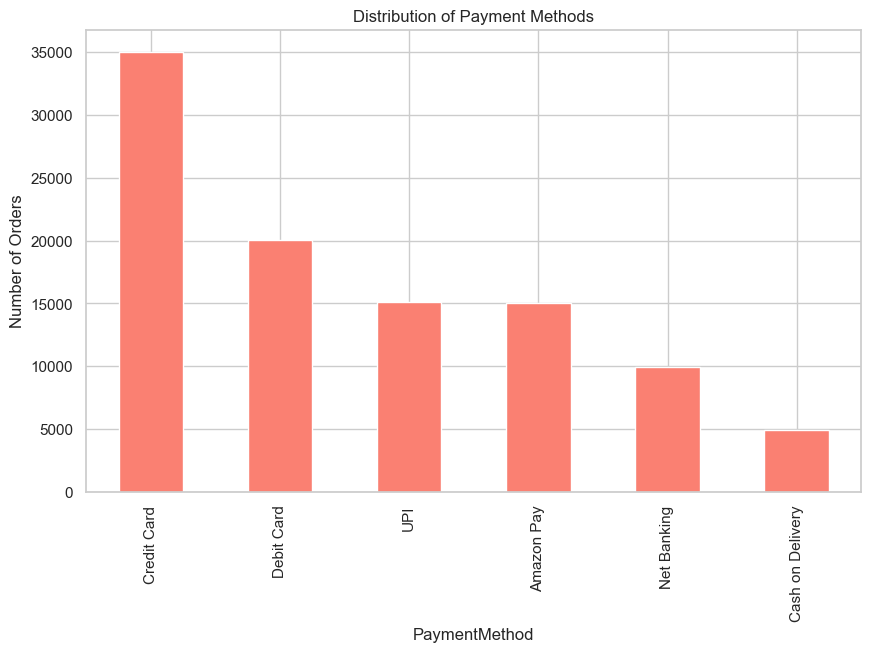

In [46]:
plt.figure(figsize=(10, 6))
df['PaymentMethod'].value_counts().plot(kind='bar', color='salmon')
plt.title("Distribution of Payment Methods")
plt.ylabel("Number of Orders")
plt.show()

<h5 style="font-size:15px;">Summary:</h5>

 * Credit Cards have the highest frequency, making them the most common choice.

 * Digital Wallets are the second most frequent, appearing moderately.

 * Bank Transfers show a lower count compared to digital options.

 * Cash on Delivery has the lowest occurrence in the dataset.

<h5 style="font-size:15px;">Insight:</h5>

Customers prefer speed and technology, so the online checkout process must stay fast and easy to keep them happy.

<h5 style="font-size:18px;">5. Profit Spread by Category (Box Plot)</h5>

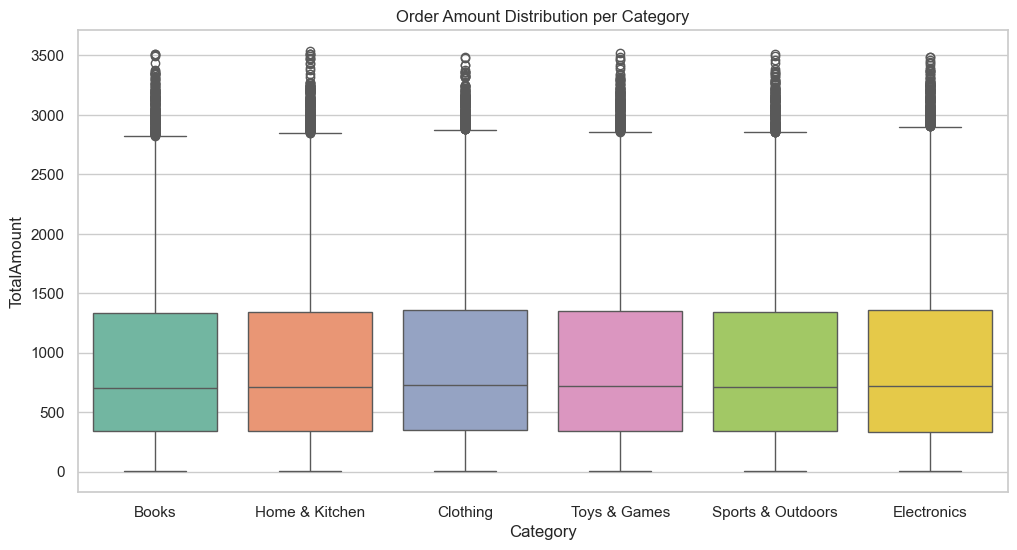

In [59]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Category', y='TotalAmount', data=df, hue='Category', palette='Set2', legend=False)
plt.title("Order Amount Distribution per Category")
plt.show()

<h5 style="font-size:15px;">Summary:</h5>

 * All categories show almost even distributions and median lines.

 * High-value outliers (up to $3500) appear across every category.

 * Median sales stay stable around the same level for all groups.

<h5 style="font-size:15px;">Insight:</h5>

The business is very balanced; customers spend about the same amount regardless of the category.

<h5 style="font-size:18px;">6. Distribution of Order Amounts (Histogram)</h5>

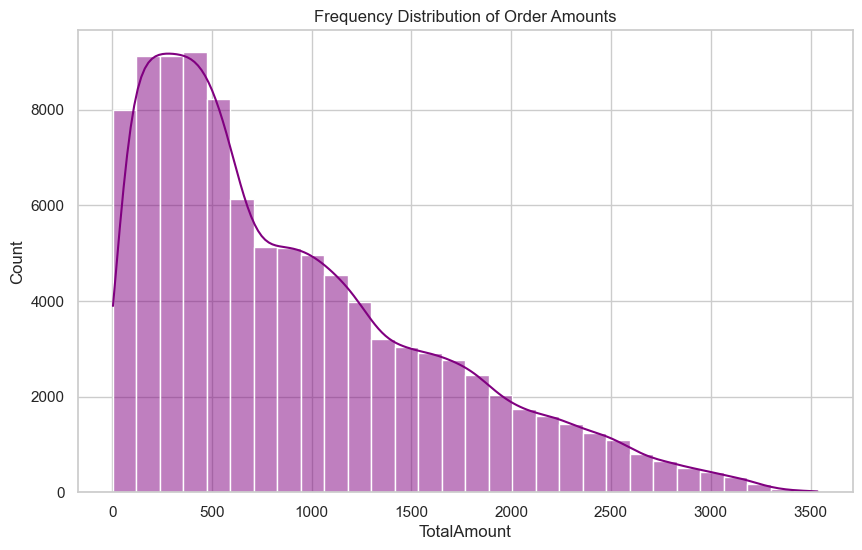

In [63]:
plt.figure(figsize=(10, 6))
sns.histplot(df['TotalAmount'], bins=30, kde=True, color='purple')
plt.title("Frequency Distribution of Order Amounts")
plt.show()

<h5 style="font-size:15px;">Summary:</h5>

 * Low-value orders have the highest frequency, appearing in the majority of records.

 * Mid-range orders appear moderately as the frequency gradually declines.

 * High-value orders have the lowest counts, appearing as rare occurrences.

 * The chart illustrates a Right-Skewed distribution of transaction values.

<h5 style="font-size:15px;">Insight:</h5>

The business survives on many small sales rather than a few big ones.

<h5 style="font-size:18px;">7. Average Order Value (AOV) by Country</h5>

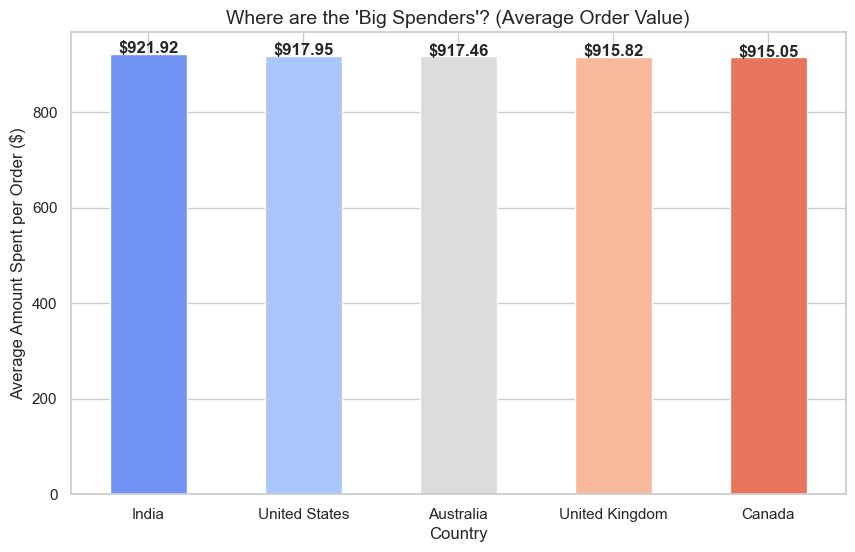

In [98]:
plt.figure(figsize=(10, 6))
colors = sns.color_palette('coolwarm', len(aov_by_country))
aov_by_country.plot(kind='bar', color=colors)

plt.title("Where are the 'Big Spenders'? (Average Order Value)", fontsize=14)
plt.ylabel("Average Amount Spent per Order ($)")
plt.xlabel("Country")
plt.xticks(rotation=0)

# Add value labels on top of bars
for i, value in enumerate(aov_by_country):
    plt.text(i, value + 2, f'${value:.2f}', ha='center', fontweight='bold')

plt.show()

<h5 style="font-size:15px;">Summary:</h5>

 * Top Spender: India leads with the highest average spend of $921.92.

 * Global Match: All countries (US, Australia, UK, Canada) are nearly identical, staying between $  951 and $ 921.

 * High Value: An average of $917+ proves customers are buying expensive, high-quality items.

<h5 style="font-size:15px;">Insight:</h5>

 * One Price Fits All: Since everyone spends the same, you don't need different "cheap" or "luxury" versions of your store for different countries.

 * Focus on Volume: Since the "amount per order" is already very high, focus on getting more orders (quantity) to grow your business.

 * Logistics Win: High-value orders are better for profit because shipping one expensive box is cheaper than shipping many small ones.

<h5 style="font-size:18px;">8. Average Shipping Cost by Category (Point Plot)</h5>

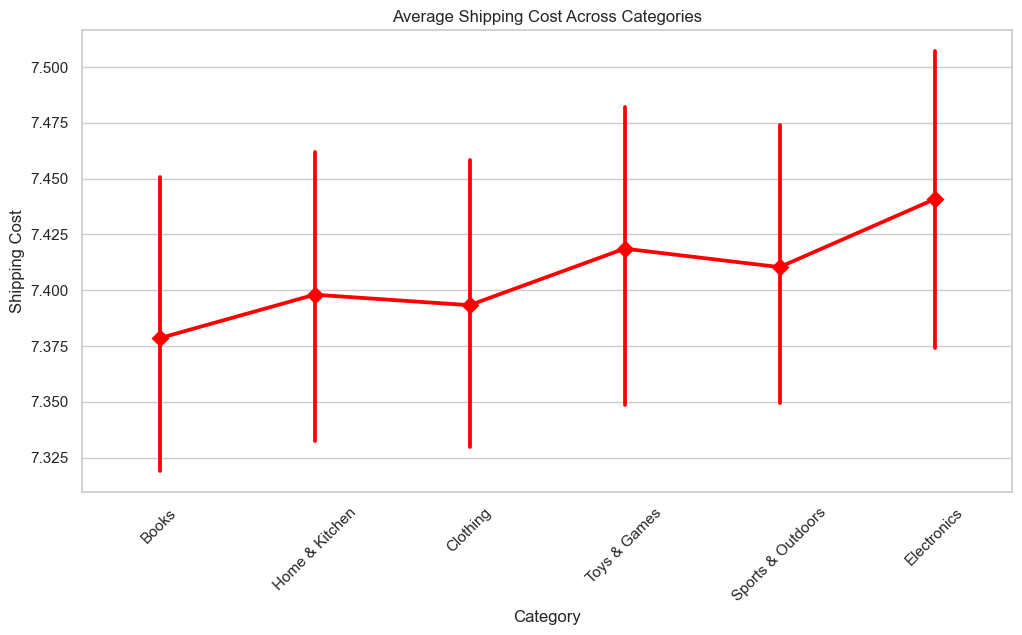

In [82]:
plt.figure(figsize=(12, 6))
# This shows a point for the average and a line for the spread
sns.pointplot(x='Category', y='ShippingCost', data=df, color='red', markers="D")
plt.title("Average Shipping Cost Across Categories")
plt.ylabel("Shipping Cost")
plt.xticks(rotation=45)
plt.show()

<h5 style="font-size:15px;">Summary:</h5>

 * Electronics has the highest average shipping cost.

 * Books have the lowest and most frequent low-cost shipping.

 * Short vertical lines show that shipping prices are very consistent within each category.

<h5 style="font-size:15px;">Insight:</h5>
    
Shipping is predictable, meaning customers face fewer surprises at checkout. However, the business should investigate ways to reduce costs for Electronics, as they are currently the most expensive to deliver.

<h5 style="font-size:18px;">9. Order Status Distribution (Stacked Bar)</h5>

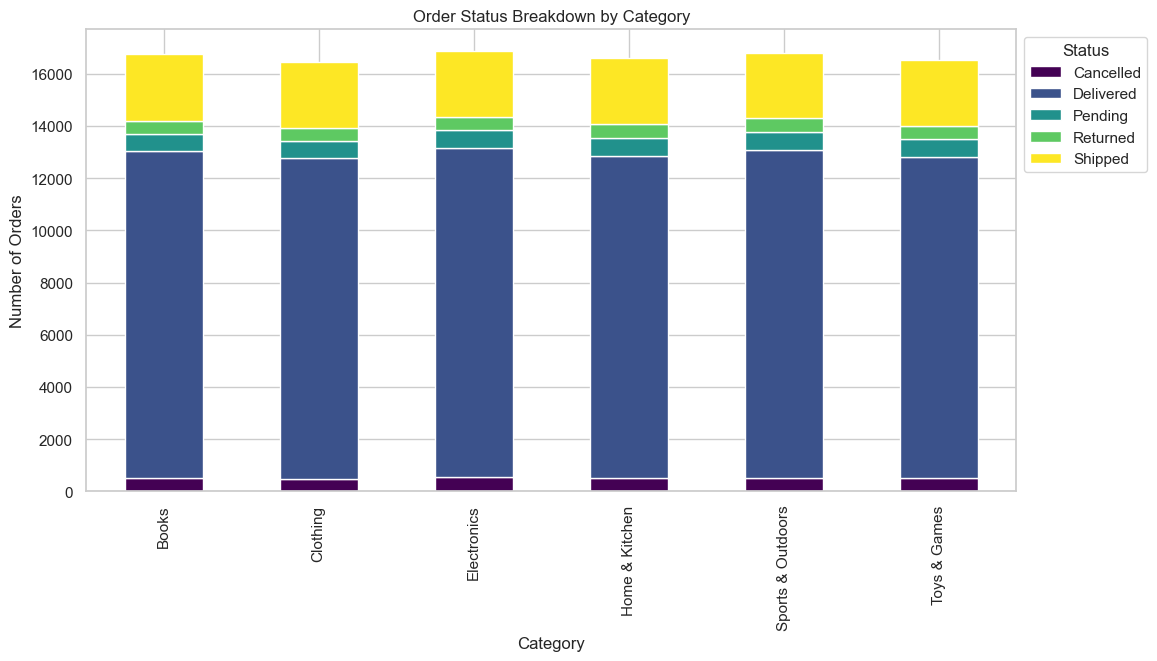

In [75]:
status_counts = pd.crosstab(df['Category'], df['OrderStatus'])
status_counts.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='viridis')
plt.title("Order Status Breakdown by Category")
plt.ylabel("Number of Orders")
plt.legend(title="Status", bbox_to_anchor=(1, 1))
plt.show()

<h5 style="font-size:15px;">Summary:</h5>

 * Delivered status makes up the highest portion of the bars in all categories.

 * Cancelled orders appear as small, almost even slices across the top.

 * Electronics has the highest total count of both successful and failed orders.

<h5 style="font-size:15px;">Insight:</h5>
    
The high percentage of "Delivered" orders shows that the supply chain is reliable. Since cancellations are low and even across all categories, there isn't one specific product type causing customer dissatisfaction.

<h5 style="font-size:18px;">10. Top 10 Brands by Revenue (Horizontal Bar)</h5>

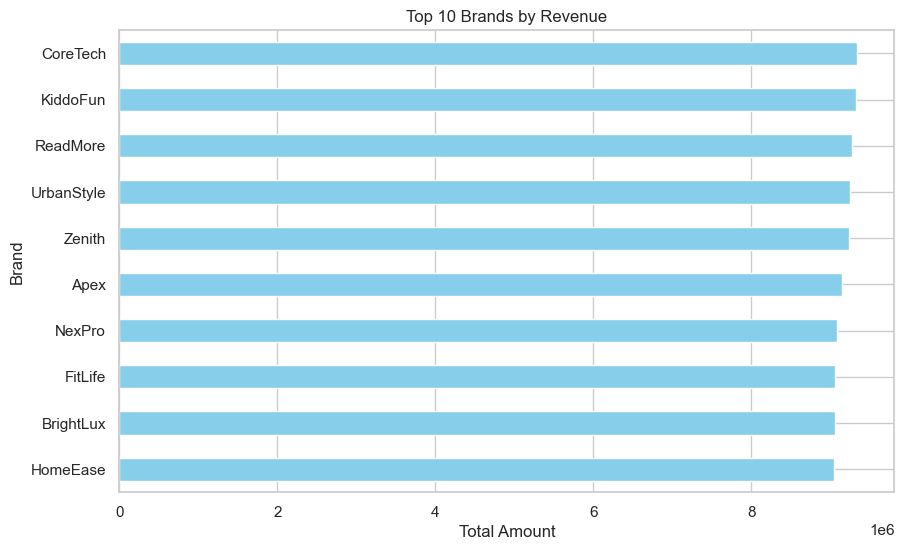

In [62]:
plt.figure(figsize=(10, 6))
df.groupby('Brand')['TotalAmount'].sum().nlargest(10).sort_values().plot(kind='barh', color='skyblue')
plt.title("Top 10 Brands by Revenue")
plt.xlabel("Total Amount")
plt.show()

<h5 style="font-size:15px;">Summary:</h5>

 * CoreTech has the highest revenue, making it the most frequent leader.

 * KiddoFun and ReadMore are the second and third most frequent contributors.

 * HomeEase and BrightLux appear at the lower end of the top 10.

 * All top 10 brands show almost even distributions, with revenue consistently high.

<h5 style="font-size:15px;">Insight:</h5>

The market is highly competitive and balanced. Since no single brand is way ahead of the others, the business is safe because it doesn't rely on just one partner.

<h2 style="font-size:25px;">INSIGHT GENERATION AND REPORT</h2>

<h2 style="font-size:20px;">Key Insights from the Analysis</h2>

1. India is the #1 Market: It leads globally with the highest average spend of $921.92 and the most orders.

2. Premium Customer Base: A global average order value of $917+ proves customers are buying high-value items rather than small, cheap goods.

3. Top Category: Clothing is the "Superstar" category, bringing in the most total revenue and order volume.

4. The "Golden Hour": Shopping activity peaks significantly between 6 PM – 10 PM, making this the most effective time for marketing.

5. Efficient Logistics: The business maintains a healthy delivery cycle of 3–6 days across all major categories.

<h2 style="font-size:20px;">Strategic Suggestions</h2>

1. Target the Evening Peak: Schedule all social media ads and email promotions between 6 PM – 10 PM to reach customers when they are most active.

2. Increase Global Volume: Since customers in the UK and Canada spend as much as those in India, launch "New Customer" discounts there to increase the total number of orders.

3. Speed Up Electronics: Improve the delivery speed for Electronics to match the 3-day window of the Books category to keep high-value shoppers happy.

4. Digital Payment Incentives: Offer a small discount for Credit Card payments in the Clothing category to reduce the reliance on Cash on Delivery (COD).

<h2 style="font-size:20px;">Conclusion</h2>

The analysis confirms that the business is in a strong and stable position with a high-value global customer base. Because the "amount spent per person" is already high and consistent worldwide, the best path to growth is increasing the number of customers in Western markets. By focusing on evening marketing and maintaining fast 3–6 day delivery, the company is well-positioned to scale successfully.